# Benchmark — October 2024
**File:** `benchmark_oct2024.ipynb` (renamed from `benchmarking_1030.ipynb`)

## Purpose
Updated benchmark run (Oct 2024) after entropy similarity pipeline refinements. Evaluates the null-adjusted scoring approach on expanded dataset.

## What is done
- Entropy similarity computation with updated peak parsing
- Null distribution p-value benchmark
- Cross-dataset validation on HILIC TTOF negative spectra
- Comparison of raw entropy vs null-adjusted score performance

## Status
ARCHIVED — Superseded by `proposal_mvp.ipynb` and `channel_ceiling.ipynb`. Retained for comparison with Mar 2024 benchmark.

## Key finding
Null-adjusted score improves calibration over raw entropy similarity. Mass-matched null outperforms random null for FDR control.


In [1]:
import numpy as np
import pandas as pd
import os
import ms_entropy as me


# Standard mapping for column names
standard_mapping = {
    "name": "Name",
    "ion_mode": "Ion Mode",
    "instrument": "Instrument",
    "instrument_type": "Instrument Type",
    "ionization": "Ionization",
    "collision_energy": "Collision Energy",
    "collision_gas": "Collision Gas",
    "sample_inlet": "Sample Inlet",
    "spectrum_type": "Spectrum Type",
    "precursor_type": "Precursor Type",
    "precursormz": "Precursor M/Z",
    "notes": "Notes",
    "inchikey": "InChIKey",
    "smiles": "SMILES",
    "synon": "Synonyms",
    "formula": "Formula",
    "mw": "Molecular Weight",
    "exactmass": "Exact Mass",
    "cas#": "CAS Number",
    "nist#": "NIST Number",
    "db#": "Database ID",
    "comments": "Comments",
    "unique_scan_number": "Unique Scan Number",
    "spectrum_id": "Spectrum ID",
    "num peaks": "Num Peaks"
}

def standardize_col(df):
    """
    Standardizes column names based on the provided mapping.

    Args:
        df (pd.DataFrame): The DataFrame whose column names need to be standardized.

    Returns:
        pd.DataFrame: DataFrame with standardized column names.
    """
    new_columns = []
    for col in df.columns:
        col_lower = col.lower().replace("reference_", "")
        standardized_col = standard_mapping.get(col_lower, col_lower)
        new_columns.append(standardized_col)
    df.columns = new_columns
    return df

def remove_zero_ions(msms):
    """
    Removes zero-intensity ions from an MS/MS spectrum.

    Args:
        msms (numpy.ndarray or float): MS/MS spectrum as a 2D NumPy array.

    Returns:
        numpy.ndarray: Filtered 2D array with non-zero intensities.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[msms[:, 1] > 0]

def sort_spectrum(msms):
    """
    Sorts MS/MS peaks by m/z value.

    Args:
        msms (numpy.ndarray): 2D numpy array with [m/z, intensity].

    Returns:
        numpy.ndarray: Sorted 2D array.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[np.argsort(msms[:, 0])]

def read_msp(file_path):
    """
    Parses an MSP file and extracts MS/MS spectra into a structured pandas DataFrame.

    Args:
        file_path (str): Path to the MSP file.

    Returns:
        pd.DataFrame: Parsed MS/MS spectra with metadata.
    """

    spectra = []
    spectrum = {}

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue  # Skip empty lines

            # Identify metadata fields
            if ":" in line:
                key, value = line.split(":", 1)
                key, value = key.strip().lower(), value.strip()

                if key == 'name':
                    # Save the previous spectrum before starting a new one
                    if spectrum:
                        spectra.append(spectrum)
                    spectrum = {'name': value, 'peaks': []}  # Start new spectrum entry
                
                else:
                    spectrum[key] = value  # Store metadata fields
            
            # Parse peak data (if line starts with a number, it's peak data)
            elif line[0].isdigit():
                try:
                    m_z, intensity = map(float, line.split()[:2])
                    spectrum['peaks'].append([m_z, intensity])
                except ValueError:
                    continue  # Ignore malformed lines

        # Save the last spectrum
        if spectrum:
            spectra.append(spectrum)

    # Convert spectra list to DataFrame
    df = pd.DataFrame(spectra)

    # Process peaks: Remove zero-intensity ions & sort by m/z
    df['peaks'] = [sort_spectrum(remove_zero_ions(np.array(peak))) for peak in df['peaks']]

    # Standardize column names
    df = standardize_col(df)

    # Convert numeric columns where applicable
    for column in df.columns:
        if column != 'peaks':  # Skip 'peaks' column
            try:
                df[column] = pd.to_numeric(df[column], errors='ignore')
            except:
                pass

    return df


In [2]:
def parse_peaks_string(peaks_str):
    """
    Parse a peaks string like:
    '[[136.0435   3.4   ]\n [214.9619  38.4   ]\n ...]'
    into a list of lists of floats.
    """
    # Remove the outer brackets and any leading/trailing whitespace
    cleaned = peaks_str.strip("[] \n")
    # Split into lines (each line corresponds to one peak row)
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        # Remove any remaining brackets and extra whitespace
        row_clean = row.strip(" []")
        if row_clean:
            # Split on whitespace and convert each element to float
            values = row_clean.split()
            result.append([float(val) for val in values])
    return result

def safe_parse_peaks(peaks):
    """
    Safely parse peaks, returning an empty list for invalid cases.
    """
    if isinstance(peaks, str):
        if "..." in peaks or peaks.strip() == "":
            return []  # Return empty list for invalid entries
        try:
            return parse_peaks_string(peaks)
        except ValueError:
            return []  # Handle unexpected format issues
    return peaks  # Already parsed peaks



In [3]:
def compute_entropy_with_parsing(peaks):
    try:
        parsed_peaks = safe_parse_peaks(peaks)
        
        # Safe check for None or NaN
        if parsed_peaks is None:
            return np.nan
        if isinstance(parsed_peaks, float) and np.isnan(parsed_peaks):
            return np.nan
            
        arr = np.array(parsed_peaks, dtype=float)
        
        # Use .size to check for emptiness instead of 'if not arr'
        if arr.size == 0:
            return np.nan
            
        return me.calculate_spectral_entropy(arr)
    except Exception as e:
        # For debugging, you can print(e) here once
        return np.nan


def add_entropy_columns(df):
    """
    Compute and append 'entropy' and 'entropy_bin' columns.
    Uses safe_parse_peaks + ms_entropy.
    """
    df["entropy"] = df["peaks"].apply(compute_entropy_with_parsing)
    df["entropy_bin"] = np.floor(df["entropy"]).astype("Int64")
    return df


In [4]:
# Path to the MSP file
file_path = "/Users/ellayoung/Downloads/MoNA-export-All_LC-MS-MS_QTOF.msp"

# Parse the MSP file
df = read_msp(file_path)

# Display parsed data
print(df.head())
df.info()

# Save to CSV
df.to_csv("parsed_spectra_mona.csv", index=False)


     Name                                              peaks       Synonyms  \
0  Zeatin  [[41.0399, 6.207207], [43.0192, 49.711712], [4...  $:00in-source   
1  Zeatin  [[43.0193, 12.172172], [57.0708, 1.157157], [6...  $:00in-source   
2  Zeatin  [[43.0192, 3.637638], [119.0351, 1.31031], [13...  $:00in-source   
3  Zeatin  [[64.0051, 2.092092], [65.0137, 8.566567], [66...  $:00in-source   
4  Zeatin  [[92.024, 5.409409], [106.0269, 2.094094], [10...  $:00in-source   

         Database ID                     InChIKey Precursor Type  \
0  VF-NPL-QTOF009997  UZKQTCBAMSWPJD-FARCUNLSSA-N         [M+H]+   
1  VF-NPL-QTOF009996  UZKQTCBAMSWPJD-FARCUNLSSA-N         [M+H]+   
2  VF-NPL-QTOF009995  UZKQTCBAMSWPJD-FARCUNLSSA-N         [M+H]+   
3  VF-NPL-QTOF009994  UZKQTCBAMSWPJD-FARCUNLSSA-N         [M-H]-   
4  VF-NPL-QTOF009993  UZKQTCBAMSWPJD-FARCUNLSSA-N         [M-H]-   

  Spectrum Type Precursor M/Z Instrument Type          Instrument Ion Mode  \
0           MS2      220.1193     LC-E

In [6]:
# df_raw = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/code/parsed_spectra_mona.csv')
df_raw = df.copy()

In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49541 entries, 0 to 49540
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              49541 non-null  object 
 1   peaks             49541 non-null  object 
 2   Synonyms          49541 non-null  object 
 3   Database ID       49541 non-null  object 
 4   InChIKey          49540 non-null  object 
 5   Precursor Type    47495 non-null  object 
 6   Spectrum Type     49176 non-null  object 
 7   Precursor M/Z     47665 non-null  object 
 8   Instrument Type   49541 non-null  object 
 9   Instrument        49532 non-null  object 
 10  Ion Mode          49540 non-null  object 
 11  Collision Energy  48053 non-null  object 
 12  Formula           49323 non-null  object 
 13  Molecular Weight  49323 non-null  float64
 14  Exact Mass        49323 non-null  float64
 15  Comments          49541 non-null  object 
 16  Num Peaks         49541 non-null  int64 

In [8]:
import pandas as pd
import numpy as np
import re

# I'll assume your raw DataFrame is called `lib_raw`
# If not, replace lib_raw with your actual variable.

df = df_raw.copy()

# 1. standardize column names -> snake_case, no spaces, lowercase
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.lower()
)

# after this, columns become:
# name, peaks, synonyms, database_id, inchikey,
# precursor_type, spectrum_type, precursor_m_z,
# instrument_type, instrument, ion_mode,
# collision_energy, formula, molecular_weight,
# exact_mass, comments, num_peaks

# 2. strip whitespace in string columns
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

# 3. coerce numeric columns that SHOULD be numeric
# precursor_m_z was object -> float
df["precursor_m_z"] = pd.to_numeric(df["precursor_m_z"], errors="coerce")


In [9]:
df_clean = df.iloc[:, [0, 1, 5, 14, 4, 3, 12,7]]

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49541 entries, 0 to 49540
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            49540 non-null  object 
 1   peaks           49541 non-null  object 
 2   precursor_type  47495 non-null  object 
 3   exact_mass      49323 non-null  float64
 4   inchikey        49540 non-null  object 
 5   database_id     49541 non-null  object 
 6   formula         49323 non-null  object 
 7   precursor_m_z   47664 non-null  float64
dtypes: float64(2), object(6)
memory usage: 3.0+ MB


In [11]:
# only include entries with M+H or M-H adducts

df_clean_mh = df_clean[df_clean["precursor_type"].isin(["[M+H]+", "[M-H]-"])]

In [12]:
df_clean_mh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40015 entries, 0 to 49540
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            40015 non-null  object 
 1   peaks           40015 non-null  object 
 2   precursor_type  40015 non-null  object 
 3   exact_mass      39907 non-null  float64
 4   inchikey        40015 non-null  object 
 5   database_id     40015 non-null  object 
 6   formula         39907 non-null  object 
 7   precursor_m_z   40014 non-null  float64
dtypes: float64(2), object(6)
memory usage: 2.7+ MB


In [13]:
df_unique = df_clean_mh.dropna(subset=['inchikey'])
df_unique = df_unique.drop_duplicates(subset=['inchikey'], keep='first')
# # # Convert NaN or float SMILES to empty strings and ensure dtype is string
# df_unique["SMILES"] = df_unique["SMILES"].fillna("").astype(str)

# Create a helper column with the first 14 characters of InChIKey
df_unique["inchi14"] = df_unique["inchikey"].astype(str).str[:14]
df_clean = df_clean_mh.dropna(subset=['inchikey'])
df_clean["inchi14"] = df_clean["inchikey"].astype(str).str[:14]

In [14]:
import numpy as np
import pandas as pd
import ms_entropy as me

def compute_entropy_with_parsing(peaks):
    try:
        # 1. Use your new helper
        parsed_peaks = safe_parse_peaks(peaks)
        
        # 2. Check for None or emptiness safely
        if parsed_peaks is None:
            return np.nan
            
        # 3. Convert to array
        arr = np.asarray(parsed_peaks, dtype=float)
        
        # 4. Check size instead of 'if not arr'
        if arr.size == 0 or arr.ndim < 2:
            return np.nan
            
        # 5. Compute entropy
        return me.calculate_spectral_entropy(arr)
        
    except Exception as e:
        # CRITICAL: If you still get 0, un-comment the line below to see the error
        # print(f"Row error: {e}")
        return np.nan

def add_entropy_columns(df):
    """
    Compute and append 'entropy' and 'entropy_bin' columns.
    """
    # Use a copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    # Calculate entropy
    df["entropy"] = df["peaks"].apply(compute_entropy_with_parsing)
    
    # Create bins (floor of entropy)
    # Using 'Int64' allows for nullable integers (keeps NaNs as <NA>)
    df["entropy_bin"] = np.floor(df["entropy"]).astype("Int64")
    
    return df

# Run the calculation
df_unique = add_entropy_columns(df_unique)
df_clean = add_entropy_columns(df_clean)

# Diagnostic check
print(f"Successfully calculated entropy for {df_unique['entropy'].count()} out of {len(df_unique)} rows.")

Successfully calculated entropy for 6089 out of 6339 rows.


In [15]:
 df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40015 entries, 0 to 49540
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            40015 non-null  object 
 1   peaks           40015 non-null  object 
 2   precursor_type  40015 non-null  object 
 3   exact_mass      39907 non-null  float64
 4   inchikey        40015 non-null  object 
 5   database_id     40015 non-null  object 
 6   formula         39907 non-null  object 
 7   precursor_m_z   40014 non-null  float64
 8   inchi14         40015 non-null  object 
 9   entropy         39145 non-null  float64
 10  entropy_bin     39145 non-null  Int64  
dtypes: Int64(1), float64(3), object(7)
memory usage: 3.7+ MB


# Same Formula Null

## Same formula, different first 14 inchis, keeps one-bond different isomers

In [16]:
import itertools
# Group by "Formula"
grouped = df_unique.groupby(["formula"])

# List to hold the isomer pairs
isomer_pairs = []

# Iterate over each group
for _, group in grouped:
    # Only consider groups with at least two entries
    if len(group) > 1:
        # Generate all unique pairs within the group
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            # Check if the first 14 characters of InChIKey differ
            if row1["inchi14"] != row2["inchi14"]:
                isomer_pairs.append((row1, row2))

# isomer_pairs now contains tuples of rows (each tuple is a pair of isomers)
print(f"Found {len(isomer_pairs)} isomer pairs meeting the criteria.")


Found 6760 isomer pairs meeting the criteria.


In [17]:
isomer_pairs[:1]

[(name                                     Methyl trans-cinnamic acid
  peaks             [[ 49.0071     2.298851]\n [ 77.0382   100.   ...
  precursor_type                                               [M+H]+
  exact_mass                                                162.06808
  inchikey                                RURHILYUWQEGOS-VOTSOKGWSA-N
  database_id                                                RP011103
  formula                                                    C10H10O2
  precursor_m_z                                              163.0754
  inchi14                                              RURHILYUWQEGOS
  entropy                                                    1.655427
  entropy_bin                                                       1
  Name: 10865, dtype: object,
  name                                               Methyl cinnamate
  peaks             [[103.05395   10.897436]\n [104.05964   15.384...
  precursor_type                                            

In [18]:
import random
from collections import defaultdict
import numpy as np

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        # Update the dictionaries so that the peaks are stored in parsed format
        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        # # Debug: print the types and content of parsed peaks
        # print("Parsed peaks types:", type(parsed_peaks1), type(parsed_peaks2))
        # print("Parsed peaks content:", parsed_peaks1, parsed_peaks2)

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            # Compute the entropy from the first spectrum's peaks (converted to a NumPy array)
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                      clean_spectrum=True,
                                                      min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    for entropy, pairs in entropy_groups.items():
        print(f"Entropy group {entropy} has {len(pairs)} pairs")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs
        
        for _ in range(num_bootstrap):
            if len(pairs) < num_pairs:
                selected_pairs = random.choices(pairs, k=num_pairs)
            else:
                selected_pairs = random.sample(pairs, num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da = 10)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)


    return null_distributions

In [19]:
formula_null = compute_random_similarity(isomer_pairs, num_pairs=5000, num_bootstrap=10)

Entropy group 2 has 2044 pairs
Entropy group 1 has 1875 pairs
Entropy group 0 has 825 pairs
Entropy group 3 has 1312 pairs
Entropy group 4 has 677 pairs
Entropy group 5 has 26 pairs
Entropy group 6 has 1 pairs


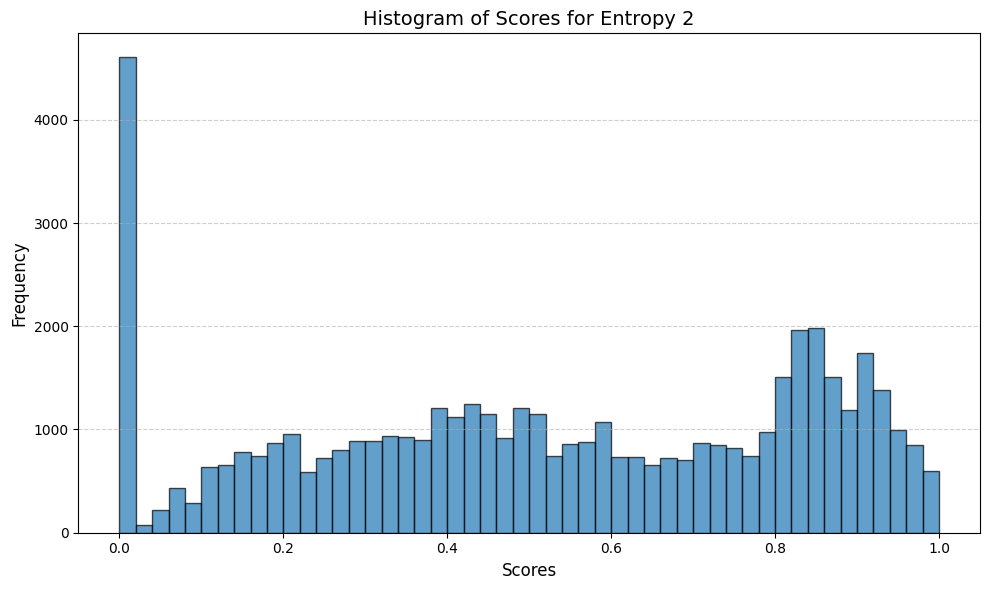

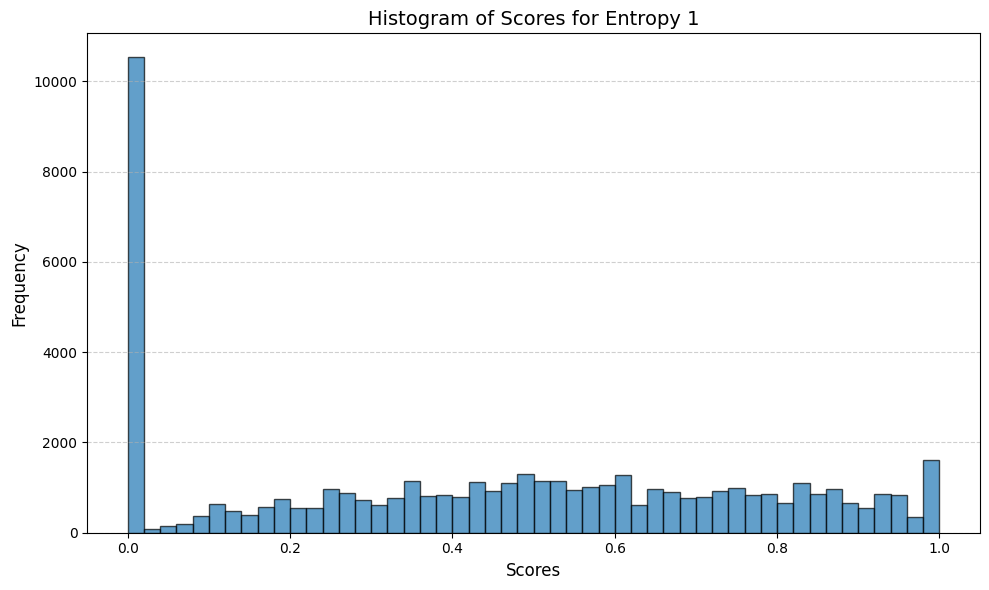

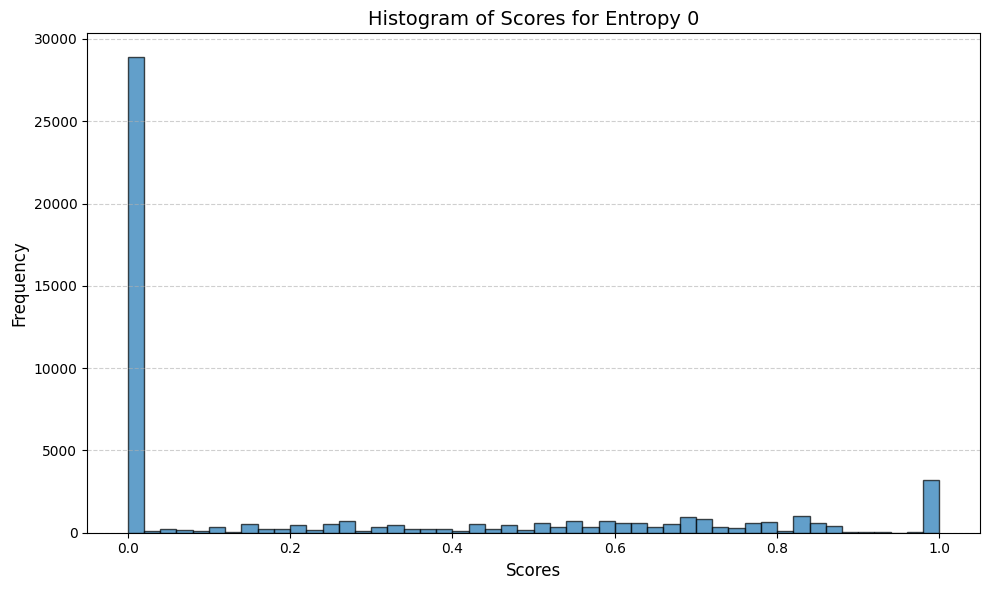

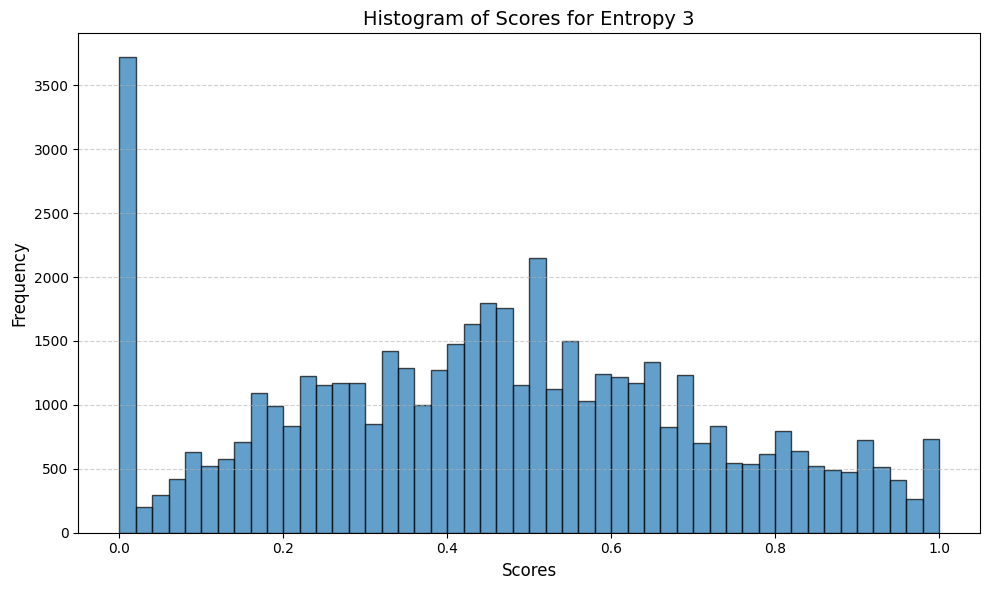

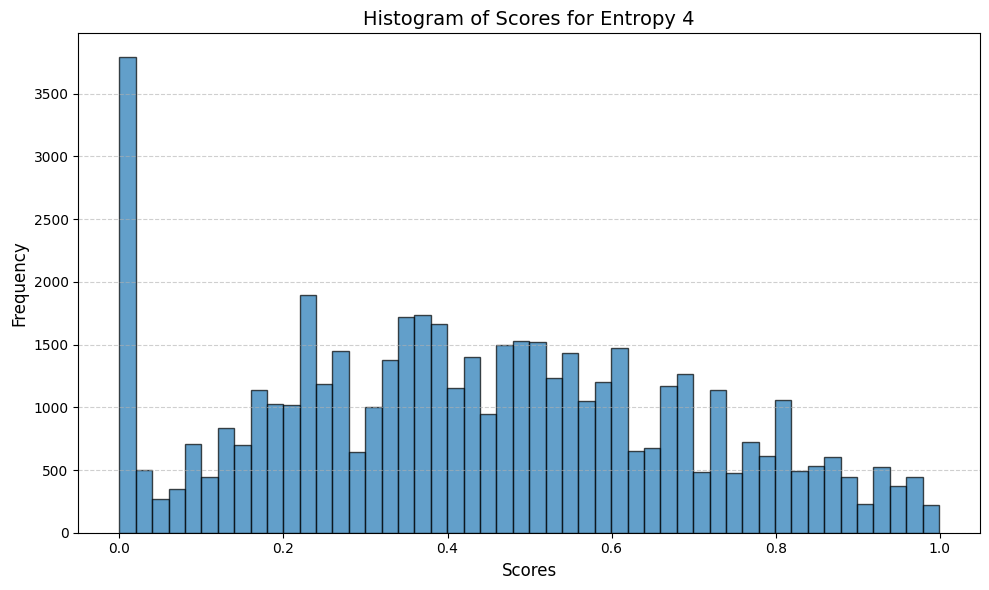

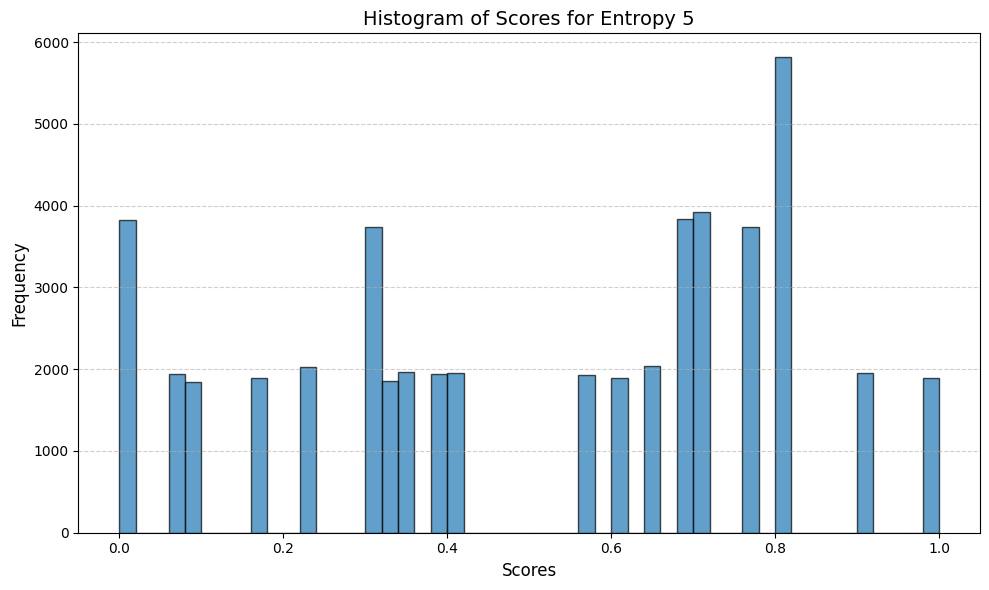

In [59]:
import matplotlib.pyplot as plt

# Iterate through entropy groups and plot histograms
for entropy, scores in formula_null.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.7, edgecolor='black')
    
    # Add titles and labels
    plt.title(f"Histogram of Scores for Entropy {entropy}", fontsize=14)
    plt.xlabel("Scores", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    
    # Improve aesthetics
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Show the plot
    plt.show()


In [76]:
print("Entropy Distribution:")
print(df_clean['entropy_bin'].value_counts().sort_index())

Entropy Distribution:
entropy_bin
0    12215
1    14885
2     7786
3     3392
4      848
5       19
Name: count, dtype: Int64


# Search against myself to create some matches to benchmark

In [21]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6339 entries, 0 to 49540
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            6339 non-null   object 
 1   peaks           6339 non-null   object 
 2   precursor_type  6339 non-null   object 
 3   exact_mass      6317 non-null   float64
 4   inchikey        6339 non-null   object 
 5   database_id     6339 non-null   object 
 6   formula         6317 non-null   object 
 7   precursor_m_z   6339 non-null   float64
 8   inchi14         6339 non-null   object 
 9   entropy         6089 non-null   float64
 10  entropy_bin     6089 non-null   Int64  
dtypes: Int64(1), float64(3), object(7)
memory usage: 600.5+ KB


In [22]:
def spectral_entropy_similarity_from_rows(peaks_a, peaks_b):
    """
    Takes raw 'peaks' entries from df_unique (string or list),
    parses both, and returns entropy similarity.
    """
    # parse both
    pa = safe_parse_peaks(peaks_a)
    pb = safe_parse_peaks(peaks_b)

    # handle bad spectra
    if not pa or not pb or isinstance(pa, float) or isinstance(pb, float):
        return np.nan

    A = np.array(pa, dtype=float)
    B = np.array(pb, dtype=float)
    if A.size == 0 or B.size == 0:
        return np.nan

    # call ms_entropy similarity
    return me.calculate_entropy_similarity(A, B)


In [23]:
def ppm_bounds(center_mz, ppm):
    tol = center_mz * ppm * 1e-6
    return center_mz - tol, center_mz + tol

def build_hits_df(df, ppm_tol=10):
    """
    Self-search the library against itself.
    Produces one row per (query, candidate) match.
    """
    rows = []

    # We'll assume df has columns:
    # "Precursor M/Z", "Ion Mode", "InChIKey", "Formula", "peaks", "entropy", "entropy_bin"

    for q_idx, q_row in df.iterrows():
        q_mz = q_row.get("precursor_m_z", np.nan)
        q_inchikey = q_row.get("inchikey", None)
        q_formula = q_row.get("formula", None)
        q_entropy = q_row.get("entropy", np.nan)
        q_bin = q_row.get("entropy_bin", np.nan)

        # skip if anything crucial is missing
        if pd.isna(q_mz) or pd.isna(q_bin):
            continue

        lo, hi = ppm_bounds(q_mz, ppm_tol)

        # basic candidate filter: same mode, within ppm
        # (OPTIONAL: also filter by same Formula if you want to reduce runtime; I won't here,
        # because in real search you'd use only mass. You decide.)
        cand = df[
            (df["precursor_m_z"].between(lo, hi))
        ]

        for l_idx, l_row in cand.iterrows():
            if l_idx == q_idx:
                continue  # skip self

            sim = spectral_entropy_similarity_from_rows(q_row["peaks"], l_row["peaks"])
            if np.isnan(sim):
                continue

            rows.append({
                "query_id": q_idx,
                "library_id": l_idx,
                "similarity": sim,
                "entropy_bin": int(q_bin) if not pd.isna(q_bin) else np.nan,
                "query_entropy": q_entropy,
                "query_mz": q_mz,
                "lib_mz": l_row.get("precursor_m_z", np.nan),
                "query_inchikey": q_inchikey,
                "lib_inchikey": l_row.get("inchikey", None),
                "query_formula": q_formula,
                "lib_formula": l_row.get("formula", None),
                # ground-truth label for evaluation:
                "is_true": (
                    pd.notna(q_inchikey)
                    and pd.notna(l_row.get("inchikey", None))
                    and (q_inchikey == l_row.get("inchikey", None))
                ),
            })

    hits_df = pd.DataFrame(rows)
    return hits_df

# build it
hits_df = build_hits_df(df_clean, ppm_tol=10)

print("hits_df shape:", hits_df.shape)
print(hits_df.head())


hits_df shape: (1201820, 12)
   query_id  library_id  similarity  entropy_bin  query_entropy  query_mz  \
0         0           1    0.608404            1        1.95726  220.1193   
1         0           2    0.390217            1        1.95726  220.1193   
2         0       10837    0.133101            1        1.95726  220.1193   
3         0       10838    0.011482            1        1.95726  220.1193   
4         0       10839    0.000000            1        1.95726  220.1193   

     lib_mz               query_inchikey                 lib_inchikey  \
0  220.1193  UZKQTCBAMSWPJD-FARCUNLSSA-N  UZKQTCBAMSWPJD-FARCUNLSSA-N   
1  220.1193  UZKQTCBAMSWPJD-FARCUNLSSA-N  UZKQTCBAMSWPJD-FARCUNLSSA-N   
2  220.1179  UZKQTCBAMSWPJD-FARCUNLSSA-N  GHOKWGTUZJEAQD-UHFFFAOYSA-N   
3  220.1179  UZKQTCBAMSWPJD-FARCUNLSSA-N  GHOKWGTUZJEAQD-UHFFFAOYSA-N   
4  220.1179  UZKQTCBAMSWPJD-FARCUNLSSA-N  GHOKWGTUZJEAQD-UHFFFAOYSA-N   

  query_formula lib_formula  is_true  
0     C10H13N5O   C10H13N5O   

In [69]:
# import numpy as np
# import pandas as pd

# def empirical_pvalue_from_formula_null(sim_obs, entropy_bin, formula_null):
#     """
#     Right-tail empirical p-value:
#     Probability that a false match would score >= sim_obs in this entropy bin.
#     Falls back to pooled null if that bin is empty.
#     """
#     if pd.isna(entropy_bin):
#         return np.nan

#     bin_key = int(entropy_bin)

#     null_scores = formula_null.get(bin_key, [])
#     if len(null_scores) == 0:
#         # fallback: pool everything
#         pooled = []
#         for v in formula_null.values():
#             pooled.extend(v)
#         null_scores = pooled

#     null_scores = np.asarray(null_scores, dtype=float)
#     if null_scores.size == 0:
#         return np.nan

#     exceed = np.sum(null_scores >= sim_obs)
#     p = (1 + exceed) / (1 + len(null_scores))
#     return p



In [77]:
# def empirical_pvalue_from_formula_null(sim_obs, entropy_bin, formula_null, min_n=100):
#     """
#     Right-tail empirical p-value with a minimum N threshold.
#     If the specific entropy bin has fewer than min_n samples, 
#     it falls back to the global distribution of all null scores.
#     """
#     if pd.isna(entropy_bin):
#         return np.nan

#     bin_key = int(entropy_bin)
#     null_scores = formula_null.get(bin_key, [])
    
#     # Check if the specific bin meets the minimum sample size requirement
#     if len(null_scores) < min_n:
#         # FALLBACK: Create a global pool from all bins combined
#         # Optimization: In a loop, you should pre-calculate this global pool 
#         # outside the function to save time.
#         pooled = []
#         for v in formula_null.values():
#             pooled.extend(v)
#         null_scores = pooled
    
#     null_scores = np.asarray(null_scores, dtype=float)
    
#     if null_scores.size == 0:
#         return np.nan

#     # Calculate empirical p-value: (1 + # null >= obs) / (1 + total null)
#     # The "+1" is the conservative 'Platt's' correction to avoid p-value of 0
#     exceed = np.sum(null_scores >= sim_obs)
#     p = (1 + exceed) / (1 + len(null_scores))
    
#     return p

In [82]:
def calculate_p_values_vectorized(hits_df, formula_null, global_pool, min_n=100):
    # 1. Prepare results array
    p_values = np.zeros(len(hits_df))
    
    # 2. Pre-sort the global pool for fast searching
    sorted_global = np.sort(global_pool)
    global_n = len(sorted_global)

    # 3. Process each bin individually (only 6 bins total)
    for bin_val in hits_df['entropy_bin'].unique():
        if pd.isna(bin_val): continue
        
        # Mask for hits in this bin
        idx = hits_df['entropy_bin'] == bin_val
        scores = hits_df.loc[idx, 'similarity'].values
        
        # Determine which null distribution to use
        null_dist = formula_null.get(int(bin_val), [])
        
        if len(null_dist) < min_n:
            # Use Global Pool
            # searchsorted returns insertion index; 
            # (N - index) = number of elements >= score
            counts = global_n - np.searchsorted(sorted_global, scores, side='left')
            p_values[idx] = (1 + counts) / (1 + global_n)
        else:
            # Use Specific Bin Pool
            sorted_null = np.sort(null_dist)
            n_null = len(sorted_null)
            counts = n_null - np.searchsorted(sorted_null, scores, side='left')
            p_values[idx] = (1 + counts) / (1 + n_null)
            
    return p_values

# Run the fast version
hits_df['p_value'] = calculate_p_values_vectorized(hits_df, formula_null, global_null_pool)
hits_df['neg_log_p'] = -np.log10(hits_df['p_value'])

print("Done! Processed 1.2M rows in seconds.")

Done! Processed 1.2M rows in seconds.


In [84]:
hits_df.head()

,query_id,library_id,similarity,entropy_bin,query_entropy,query_mz,lib_mz,query_inchikey,lib_inchikey,query_formula,lib_formula,is_true,p_emp,p_adj_local,p_value,neg_log_p
0,0,1,0.608404,1,1.95726,220.1193,220.1193,UZKQTCBAMSWPJD-FARCUNLSSA-N,UZKQTCBAMSWPJD-FARCUNLSSA-N,C10H13N5O,C10H13N5O,True,0.334273,1.0,0.334273,0.475898
1,0,2,0.390217,1,1.95726,220.1193,220.1193,UZKQTCBAMSWPJD-FARCUNLSSA-N,UZKQTCBAMSWPJD-FARCUNLSSA-N,C10H13N5O,C10H13N5O,True,0.569589,1.0,0.569589,0.244439
2,0,10837,0.133101,1,1.95726,220.1193,220.1179,UZKQTCBAMSWPJD-FARCUNLSSA-N,GHOKWGTUZJEAQD-UHFFFAOYSA-N,C10H13N5O,C9H17NO5,False,0.754445,1.0,0.754445,0.122372
3,0,10838,0.011482,1,1.95726,220.1193,220.1179,UZKQTCBAMSWPJD-FARCUNLSSA-N,GHOKWGTUZJEAQD-UHFFFAOYSA-N,C10H13N5O,C9H17NO5,False,0.789204,1.0,0.789204,0.102811
4,0,10839,0.000000,1,1.95726,220.1193,220.1179,UZKQTCBAMSWPJD-FARCUNLSSA-N,GHOKWGTUZJEAQD-UHFFFAOYSA-N,C10H13N5O,C9H17NO5,False,1.000000,1.0,1.000000,-0.000000


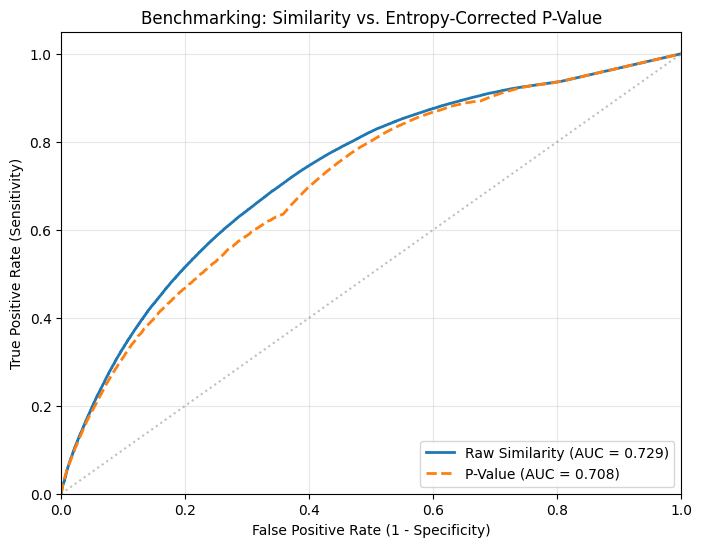

In [85]:
def plot_roc_comparison(df):
    plt.figure(figsize=(8, 6))
    
    # 1. ROC for Raw Similarity
    fpr_sim, tpr_sim, _ = roc_curve(df['is_true'], df['similarity'])
    roc_auc_sim = auc(fpr_sim, tpr_sim)
    plt.plot(fpr_sim, tpr_sim, label=f'Raw Similarity (AUC = {roc_auc_sim:.3f})', lw=2)
    
    # 2. ROC for Entropy-Corrected P-Value
    # We use neg_log_p because higher values indicate better matches
    fpr_p, tpr_p, _ = roc_curve(df['is_true'], df['neg_log_p'])
    roc_auc_p = auc(fpr_p, tpr_p)
    plt.plot(fpr_p, tpr_p, label=f'P-Value (AUC = {roc_auc_p:.3f})', linestyle='--', lw=2)
    
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Benchmarking: Similarity vs. Entropy-Corrected P-Value')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_comparison(hits_df)

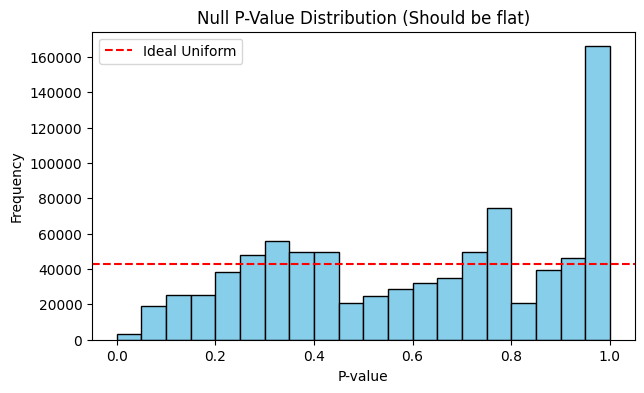

In [86]:
plt.figure(figsize=(7, 4))
plt.hist(hits_df[hits_df['is_true'] == False]['p_value'], bins=20, color='skyblue', edgecolor='black')
plt.axhline(y=len(hits_df[hits_df['is_true'] == False])/20, color='red', linestyle='--', label='Ideal Uniform')
plt.title("Null P-Value Distribution (Should be flat)")
plt.xlabel("P-value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

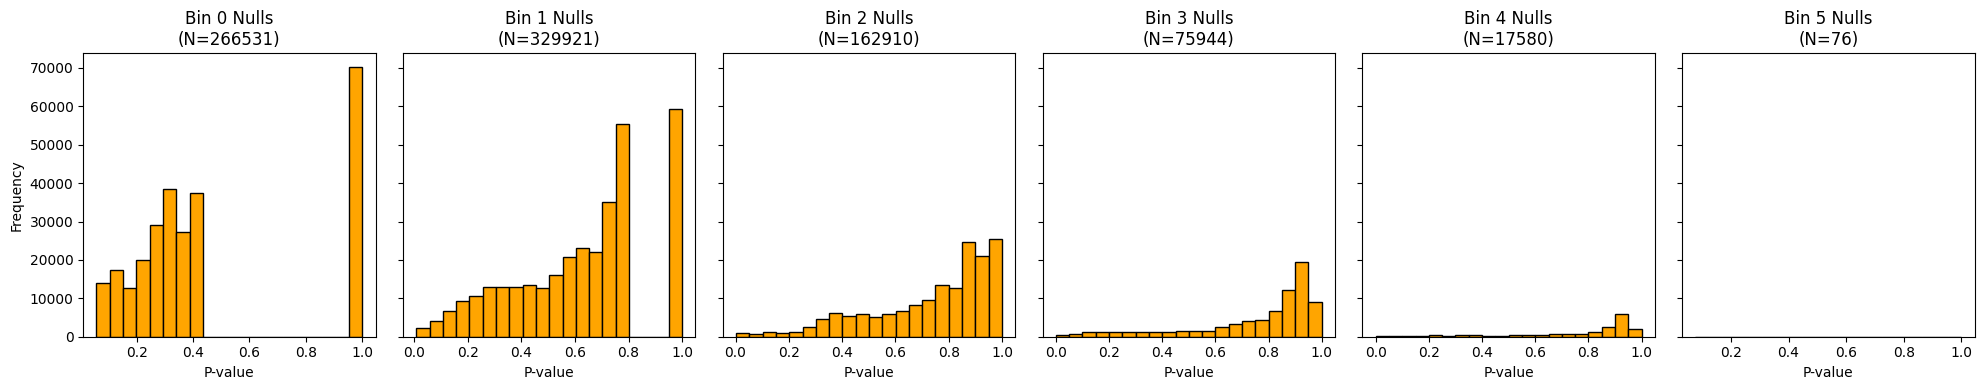

In [87]:
def plot_stratified_pvalues(df):
    bins = sorted(df['entropy_bin'].dropna().unique())
    fig, axes = plt.subplots(1, len(bins), figsize=(20, 4), sharey=True)
    
    for i, b in enumerate(bins):
        subset = df[(df['entropy_bin'] == b) & (df['is_true'] == False)]
        if len(subset) > 0:
            axes[i].hist(subset['p_value'], bins=20, color='orange', edgecolor='black')
            axes[i].set_title(f"Bin {b} Nulls\n(N={len(subset)})")
            axes[i].set_xlabel("P-value")
    
    axes[0].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_stratified_pvalues(hits_df)

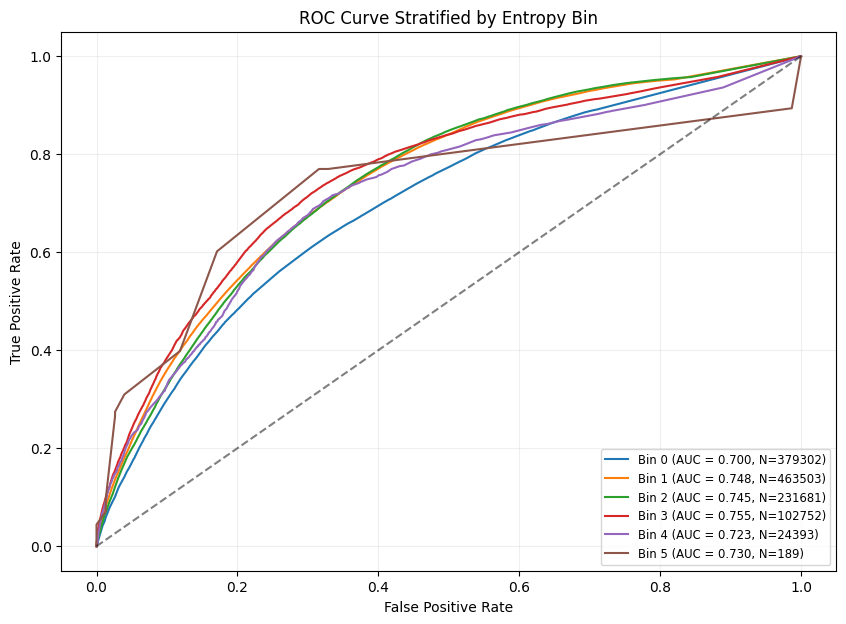

[0.         0.         0.01315789 0.01315789 0.02631579 0.02631579
 0.03947368 0.11842105 0.17105263 0.31578947 0.32894737 0.98684211
 1.        ] [0.         0.04424779 0.07079646 0.09734513 0.26548673 0.27433628
 0.30973451 0.39823009 0.60176991 0.7699115  0.7699115  0.89380531
 1.        ]


In [89]:
def plot_stratified_roc(df):
    plt.figure(figsize=(10, 7))
    bins = sorted(df['entropy_bin'].dropna().unique())
    
    for b in bins:
        subset = df[df['entropy_bin'] == b]
        if len(subset['is_true'].unique()) < 2: continue # Need both T and F
        
        # Calculate AUC for P-values in this bin
        fpr, tpr, _ = roc_curve(subset['is_true'], subset['neg_log_p'])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'Bin {b} (AUC = {roc_auc:.3f}, N={len(subset)})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Stratified by Entropy Bin')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.2)
    plt.show()
    print(fpr, tpr)

plot_stratified_roc(hits_df)

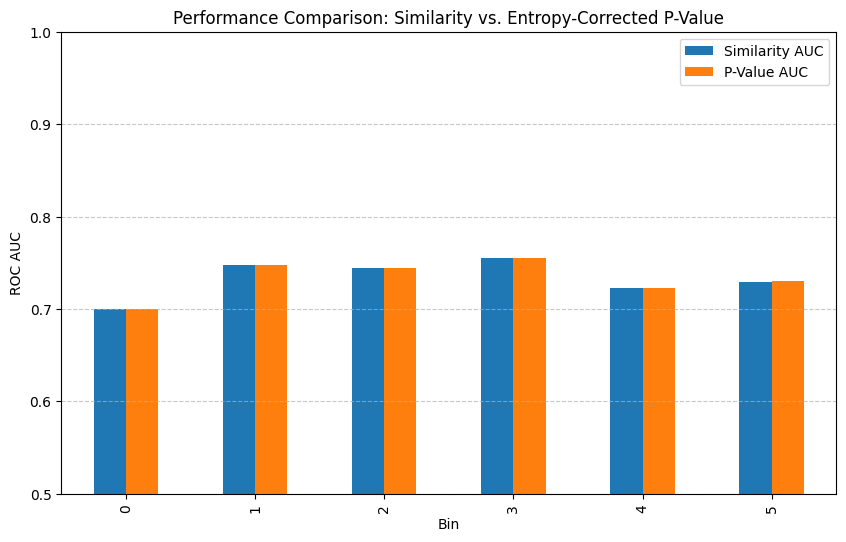

   Bin  Similarity AUC  P-Value AUC      Gain
0    0        0.700232     0.700217 -0.000015
1    1        0.748024     0.748023 -0.000001
2    2        0.744876     0.744864 -0.000012
3    3        0.755574     0.755495 -0.000079
4    4        0.722819     0.722823  0.000003
5    5        0.729506     0.730380  0.000873


In [90]:
def plot_auc_gain_by_bin(df):
    bins = sorted(df['entropy_bin'].dropna().unique())
    results = []

    for b in bins:
        subset = df[df['entropy_bin'] == b]
        if len(subset['is_true'].unique()) < 2: continue
        
        # AUC for Similarity
        fpr_s, tpr_s, _ = roc_curve(subset['is_true'], subset['similarity'])
        auc_sim = auc(fpr_s, tpr_s)
        
        # AUC for P-value
        fpr_p, tpr_p, _ = roc_curve(subset['is_true'], subset['neg_log_p'])
        auc_p = auc(fpr_p, tpr_p)
        
        results.append({'Bin': b, 'Similarity AUC': auc_sim, 'P-Value AUC': auc_p, 'Gain': auc_p - auc_sim})

    res_df = pd.DataFrame(results)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    res_df.set_index('Bin')[['Similarity AUC', 'P-Value AUC']].plot(kind='bar', ax=ax)
    plt.title("Performance Comparison: Similarity vs. Entropy-Corrected P-Value")
    plt.ylabel("ROC AUC")
    plt.ylim(0.5, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return res_df

comparison_results = plot_auc_gain_by_bin(hits_df)
print(comparison_results)

In [91]:
from sklearn.metrics import roc_curve, auc

def calculate_global_gain(df):
    # Calculate Global ROC for Raw Similarity
    fpr_s, tpr_s, _ = roc_curve(df['is_true'], df['similarity'])
    global_auc_sim = auc(fpr_s, tpr_s)
    
    # Calculate Global ROC for Entropy-Corrected P-Value
    # (Higher neg_log_p is better)
    fpr_p, tpr_p, _ = roc_curve(df['is_true'], df['neg_log_p'])
    global_auc_p = auc(fpr_p, tpr_p)
    
    print(f"Global Similarity AUC: {global_auc_sim:.4f}")
    print(f"Global P-Value AUC:    {global_auc_p:.4f}")
    print(f"TOTAL GLOBAL GAIN:     {global_auc_p - global_auc_sim:.4f}")

calculate_global_gain(hits_df)

Global Similarity AUC: 0.7293
Global P-Value AUC:    0.7080
TOTAL GLOBAL GAIN:     -0.0213


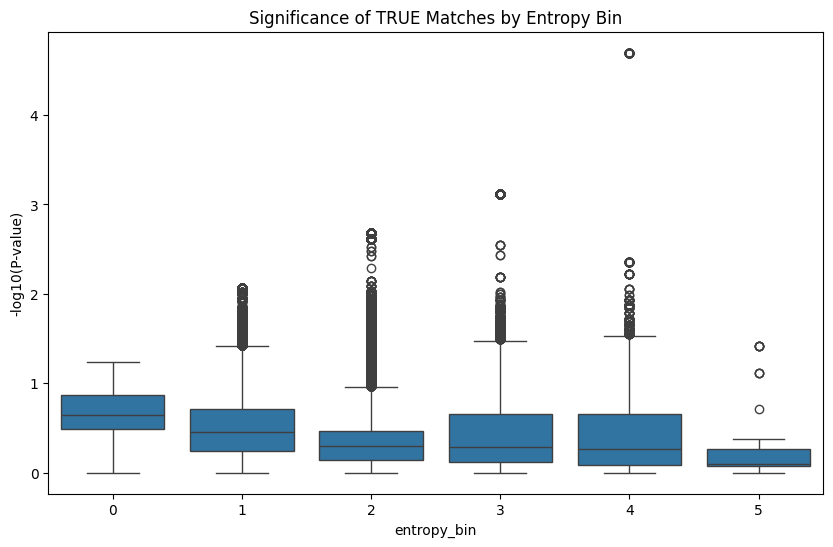

In [92]:
import seaborn as sns

def analyze_calibration(df):
    plt.figure(figsize=(10, 6))
    # Look only at TRUE matches
    true_hits = df[df['is_true'] == True]
    
    # Plot the distribution of -log10(p) for each bin
    sns.boxplot(data=true_hits, x='entropy_bin', y='neg_log_p')
    plt.title("Significance of TRUE Matches by Entropy Bin")
    plt.ylabel("-log10(P-value)")
    plt.show()

analyze_calibration(hits_df)

In [94]:
import numpy as np
import pandas as pd

def calculate_z_scores(df, formula_null):
    # 1. Pre-calculate mean and std for each entropy bin
    bin_stats = {}
    global_scores = np.concatenate([np.asarray(v) for v in formula_null.values() if len(v) > 0])
    global_mean = np.mean(global_scores)
    global_std = np.std(global_scores)

    for b, scores in formula_null.items():
        if len(scores) > 1:
            bin_stats[int(b)] = (np.mean(scores), np.std(scores))
        else:
            # Fallback to global if bin is too small/empty
            bin_stats[int(b)] = (global_mean, global_std)

    # 2. Map stats to the hits_df
    # We create helper columns to perform vectorized math
    means = df['entropy_bin'].map(lambda x: bin_stats.get(int(x), (global_mean, global_std))[0])
    stds = df['entropy_bin'].map(lambda x: bin_stats.get(int(x), (global_mean, global_std))[1])

    # 3. Calculate Z-score: (Observed - Mean) / Std
    # We add a tiny epsilon to std to prevent division by zero
    z_scores = (df['similarity'] - means) / (stds + 1e-9)
    
    return z_scores

# Apply to hits_df
hits_df['z_score'] = calculate_z_scores(hits_df, formula_null)

print("Z-scores calculated. Range:", hits_df['z_score'].min(), "to", hits_df['z_score'].max())

Z-scores calculated. Range: -1.7598398651841014 to 2.2242466172909596


Raw Similarity AUC: 0.7293
P-Value (-log10) AUC: 0.7080
Z-Score AUC: 0.7181


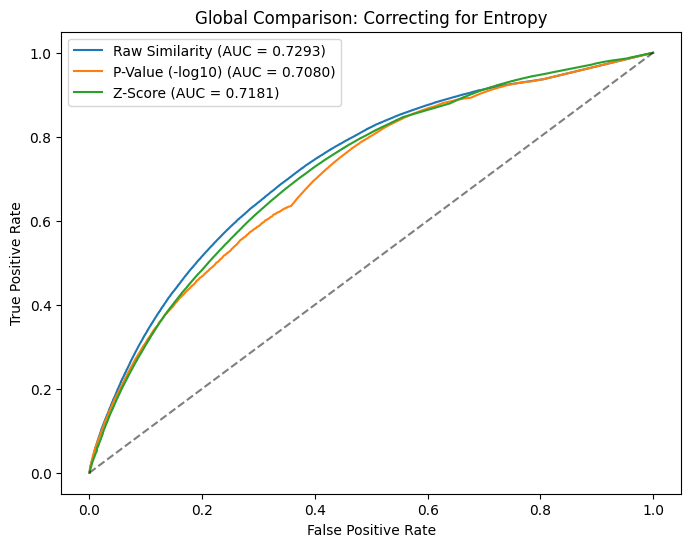

In [95]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def compare_metrics(df):
    plt.figure(figsize=(8, 6))
    
    metrics = {
        'Raw Similarity': df['similarity'],
        'P-Value (-log10)': df['neg_log_p'],
        'Z-Score': df['z_score']
    }
    
    for name, scores in metrics.items():
        # Handle NaNs if any
        mask = ~np.isnan(scores)
        fpr, tpr, _ = roc_curve(df.loc[mask, 'is_true'], scores[mask])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
        print(f"{name} AUC: {roc_auc:.4f}")

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Global Comparison: Correcting for Entropy')
    plt.legend()
    plt.show()

compare_metrics(hits_df)

In [98]:
from sklearn.metrics import log_loss
# Assuming you've scaled your similarity or p-value to [0,1]
loss_sim = log_loss(hits_df['is_true'], hits_df['similarity'])
loss_pval = log_loss(hits_df['is_true'], 1 - hits_df['p_value']) 
print(f"Log Loss Improvement: {loss_sim - loss_pval}")

Log Loss Improvement: -0.03176927213903191


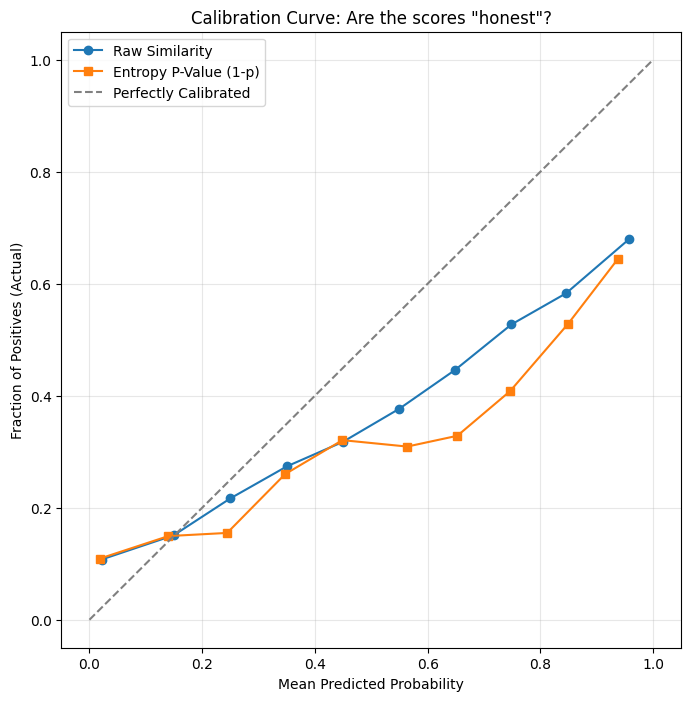

In [99]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_calibration_curves(df):
    plt.figure(figsize=(8, 8))
    
    # 1. Similarity Calibration
    # We assume similarity 0-1 acts as a probability
    prob_true_sim, prob_pred_sim = calibration_curve(df['is_true'], df['similarity'], n_bins=10)
    
    # 2. P-Value Calibration
    # (1 - p_value) is the probability that it is NOT a null match
    p_prob = 1 - df['p_value']
    prob_true_p, prob_pred_p = calibration_curve(df['is_true'], p_prob, n_bins=10)
    
    # Plotting
    plt.plot(prob_pred_sim, prob_true_sim, marker='o', label='Raw Similarity')
    plt.plot(prob_pred_p, prob_true_p, marker='s', label='Entropy P-Value (1-p)')
    
    # The "Perfect" Line
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives (Actual)')
    plt.title('Calibration Curve: Are the scores "honest"?')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_calibration_curves(hits_df)

# Likelihood Ratio Approach

In [24]:
def calculate_lr_histogram(df, formula_null, n_bins=100):
    lr_results = np.ones(len(df))
    
    for b in sorted(df['entropy_bin'].unique()):
        if np.isnan(b): continue
        
        idx = (df['entropy_bin'] == b)
        bin_scores = df.loc[idx, 'similarity'].values
        
        null_dist = np.asarray(formula_null.get(int(b), []))
        true_dist = df[(df['entropy_bin'] == b) & (df['is_true'] == True)]['similarity'].values
        
        if len(null_dist) < 20 or len(true_dist) < 20:
            continue
            
        # 1. Create Histograms (Densities)
        # We use a fixed range [0, 1] for similarity
        null_hist, bin_edges = np.histogram(null_dist, bins=n_bins, range=(0, 1), density=True)
        true_hist, _ = np.histogram(true_dist, bins=n_bins, range=(0, 1), density=True)
        
        # 2. Map bin_scores to the histogram indices
        # np.digitize tells us which histogram "bucket" each score falls into
        bin_indices = np.digitize(bin_scores, bin_edges) - 1
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)
        
        # 3. Extract likelihoods
        l_null = null_hist[bin_indices]
        l_true = true_hist[bin_indices]
        
        # 4. Store LR (with epsilon to avoid 0/0)
        lr_results[idx] = (l_true + 1e-6) / (l_null + 1e-6)
        
    return lr_results

# This will run in ~2-5 seconds
hits_df['likelihood_ratio'] = calculate_lr_histogram(hits_df, formula_null)
hits_df['log_lr'] = np.log10(hits_df['likelihood_ratio'])

In [27]:
from sklearn.metrics import roc_curve, auc

# Global Comparison
fpr_sim, tpr_sim, _ = roc_curve(hits_df['is_true'], hits_df['similarity'])
fpr_lr, tpr_lr, _ = roc_curve(hits_df['is_true'], hits_df['log_lr'])

print(f"Global Similarity AUC: {auc(fpr_sim, tpr_sim):.4f}")
print(f"Global Likelihood Ratio AUC: {auc(fpr_lr, tpr_lr):.4f}")

Global Similarity AUC: 0.7293
Global Likelihood Ratio AUC: 0.5763


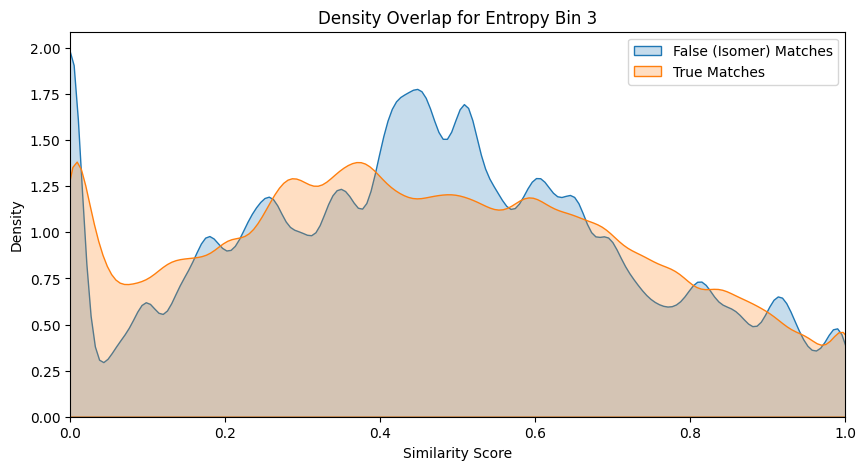

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def debug_distributions(df, formula_null, bin_to_check=3):
    plt.figure(figsize=(10, 5))
    
    # 1. Get the data for one specific bin
    null_scores = np.asarray(formula_null.get(bin_to_check, []))
    true_scores = df[(df['entropy_bin'] == bin_to_check) & (df['is_true'] == True)]['similarity'].values
    
    # 2. Plot Densities
    sns.kdeplot(null_scores, label='False (Isomer) Matches', fill=True, bw_adjust=0.5)
    sns.kdeplot(true_scores, label='True Matches', fill=True, bw_adjust=0.5)
    
    plt.title(f"Density Overlap for Entropy Bin {bin_to_check}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Density")
    plt.legend()
    plt.xlim(0, 1)
    plt.show()

debug_distributions(hits_df, formula_null, bin_to_check=3)

In [29]:
def calculate_lr_quantiles(df, formula_null):
    # Instead of probability density, use the ratio of percentiles
    lr_results = np.ones(len(df))
    
    for b in sorted(df['entropy_bin'].unique()):
        if np.isnan(b): continue
        idx = (df['entropy_bin'] == b)
        bin_scores = df.loc[idx, 'similarity'].values
        
        null_dist = np.sort(np.asarray(formula_null.get(int(b), [])))
        true_dist = np.sort(df[(df['entropy_bin'] == b) & (df['is_true'] == True)]['similarity'].values)
        
        if len(null_dist) < 20 or len(true_dist) < 20: continue
            
        # For each score, find its "rank" in the True and Null distributions
        # We use searchsorted to find the percentile rank
        true_ranks = np.searchsorted(true_dist, bin_scores) / len(true_dist)
        null_ranks = np.searchsorted(null_dist, bin_scores) / len(null_dist)
        
        # LR is the ratio of how much more "extreme" a score is in the True vs Null
        # Adding epsilon to avoid division by zero
        lr_results[idx] = (true_ranks + 0.01) / (null_ranks + 0.01)
        
    return lr_results

hits_df['lr_quant'] = calculate_lr_quantiles(hits_df, formula_null)

In [30]:
from sklearn.metrics import roc_curve, auc

# Global Comparison
fpr_sim, tpr_sim, _ = roc_curve(hits_df['is_true'], hits_df['similarity'])
fpr_lr, tpr_lr, _ = roc_curve(hits_df['is_true'], hits_df['lr_quant'])

print(f"Global Similarity AUC: {auc(fpr_sim, tpr_sim):.4f}")
print(f"Global Likelihood Ratio AUC: {auc(fpr_lr, tpr_lr):.4f}")

Global Similarity AUC: 0.7293
Global Likelihood Ratio AUC: 0.5689


# End of likelihood ratio approach

# Bonus Score?

In [31]:
def calculate_bin_weighted_score(df):
    # Calculate the 'success rate' of each bin
    # (How much better are True matches than False matches on average?)
    bin_bonus = {}
    for b in df['entropy_bin'].unique():
        sub = df[df['entropy_bin'] == b]
        true_avg = sub[sub['is_true'] == True]['similarity'].mean()
        false_avg = sub[sub['is_true'] == False]['similarity'].mean()
        # The bonus is the 'separation' in that bin
        bin_bonus[b] = max(0, true_avg - false_avg)
    
    # New Score = Similarity + Bin Bonus
    return df['similarity'] + df['entropy_bin'].map(bin_bonus)

hits_df['bonus_score'] = calculate_bin_weighted_score(hits_df)

In [33]:
from sklearn.metrics import roc_curve, auc

# Global Comparison
fpr_sim, tpr_sim, _ = roc_curve(hits_df['is_true'], hits_df['similarity'])
fpr_lr, tpr_lr, _ = roc_curve(hits_df['is_true'], hits_df['bonus_score'])

print(f"Global Similarity AUC: {auc(fpr_sim, tpr_sim):.4f}")
print(f"Global Bonus Score AUC: {auc(fpr_lr, tpr_lr):.4f}")

Global Similarity AUC: 0.7293
Global Bonus Score AUC: 0.7285


In [34]:
def generate_separation_table(df):
    results = []
    
    for b in sorted(df['entropy_bin'].unique()):
        if np.isnan(b): continue
        
        subset = df[df['entropy_bin'] == b]
        true_scores = subset[subset['is_true'] == True]['similarity']
        false_scores = subset[subset['is_true'] == False]['similarity']
        
        if len(true_scores) > 0 and len(false_scores) > 0:
            t_mean = true_scores.mean()
            f_mean = false_scores.mean()
            # Cohen's d (Effect Size) is a better metric for 'Separation' than just the difference
            pooled_std = np.sqrt((true_scores.std()**2 + false_scores.std()**2) / 2)
            cohens_d = (t_mean - f_mean) / pooled_std if pooled_std > 0 else 0
            
            results.append({
                'Bin (Entropy)': b,
                'N_True': len(true_scores),
                'N_False': len(false_scores),
                'True_Mean': round(t_mean, 4),
                'False_Mean': round(f_mean, 4),
                'Separation (Delta)': round(t_mean - f_mean, 4),
                'Effect Size (Cohen d)': round(cohens_d, 4)
            })
            
    return pd.DataFrame(results)

separation_df = generate_separation_table(hits_df)
print(separation_df.to_string(index=False))

 Bin (Entropy)  N_True  N_False  True_Mean  False_Mean  Separation (Delta)  Effect Size (Cohen d)
             0  112771   266531     0.5422      0.3247              0.2175                 0.7404
             1  133582   329921     0.5617      0.3093              0.2524                 0.9563
             2   68771   162910     0.5083      0.2684              0.2399                 0.9301
             3   26808    75944     0.4526      0.2148              0.2378                 0.9799
             4    6813    17580     0.4245      0.2028              0.2216                 0.8468
             5     113       76     0.2764      0.0889              0.1875                 0.9209


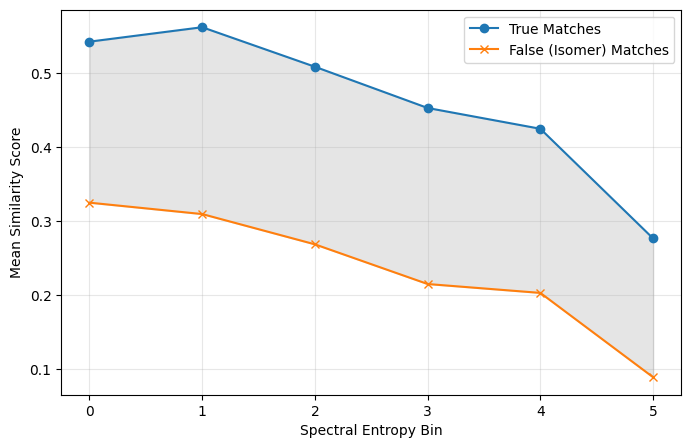

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(separation_df['Bin (Entropy)'], separation_df['True_Mean'], marker='o', label='True Matches')
plt.plot(separation_df['Bin (Entropy)'], separation_df['False_Mean'], marker='x', label='False (Isomer) Matches')
plt.fill_between(separation_df['Bin (Entropy)'], separation_df['False_Mean'], separation_df['True_Mean'], alpha=0.2, color='gray')
plt.xlabel('Spectral Entropy Bin')
plt.ylabel('Mean Similarity Score')
# plt.title('The Entropy-Score Paradox: Separation remains while scores drop')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def calculate_probabilities(df):
    # Initialize the probability column
    probs = np.zeros(len(df))
    
    # We calibrate each bin individually
    for b in sorted(df['entropy_bin'].unique()):
        if np.isnan(b): continue
        
        # Select data for this bin
        mask = (df['entropy_bin'] == b)
        bin_data = df[mask]
        
        # We need both True and False examples to train the calibration
        if len(bin_data['is_true'].unique()) < 2:
            continue
            
        # Fit a Logistic Regression (Platt Scaling)
        # X is the similarity, y is the is_true label
        lr = LogisticRegression()
        X = bin_data['similarity'].values.reshape(-1, 1)
        y = bin_data['is_true'].values
        
        lr.fit(X, y)
        
        # Predict probability for all rows in this bin
        # lr.predict_proba returns [prob_false, prob_true]
        probs[mask] = lr.predict_proba(X)[:, 1]
        
    return probs

# Apply the calibration
hits_df['match_probability'] = calculate_probabilities(hits_df)

In [37]:
from sklearn.metrics import roc_curve, auc

# Global Comparison
fpr_sim, tpr_sim, _ = roc_curve(hits_df['is_true'], hits_df['similarity'])
fpr_lr, tpr_lr, _ = roc_curve(hits_df['is_true'], hits_df['match_probability'])

print(f"Global Similarity AUC: {auc(fpr_sim, tpr_sim):.4f}")
print(f"Match Probability AUC: {auc(fpr_lr, tpr_lr):.4f}")

Global Similarity AUC: 0.7293
Match Probability AUC: 0.7343


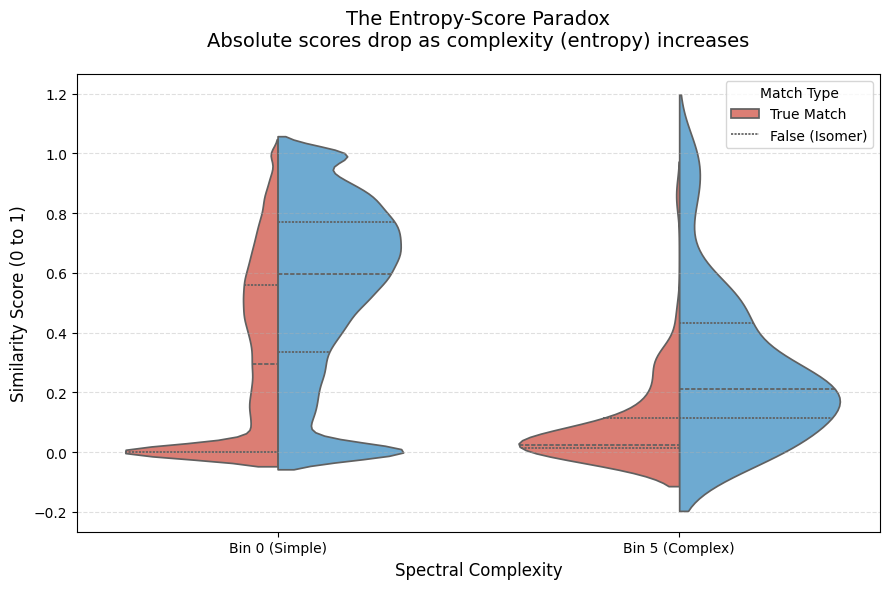

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for the extreme bins to highlight the contrast
plot_df = hits_df[hits_df['entropy_bin'].isin([0, 5])].copy()
plot_df['Bin Label'] = plot_df['entropy_bin'].map({0: 'Bin 0 (Simple)', 5: 'Bin 5 (Complex)'})

plt.figure(figsize=(9, 6))

# 2. Create the split violin plot
sns.violinplot(data=plot_df, x='Bin Label', y='similarity', hue='is_true', 
               split=True, inner="quart", palette={True: "#5DADE2", False: "#EC7063"})

# 3. Add statistical context and styling
plt.title("The Entropy-Score Paradox\nAbsolute scores drop as complexity (entropy) increases", fontsize=14, pad=20)
plt.ylabel("Similarity Score (0 to 1)", fontsize=12)
plt.xlabel("Spectral Complexity", fontsize=12)
plt.legend(title="Match Type", labels=["True Match", "False (Isomer)"])
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

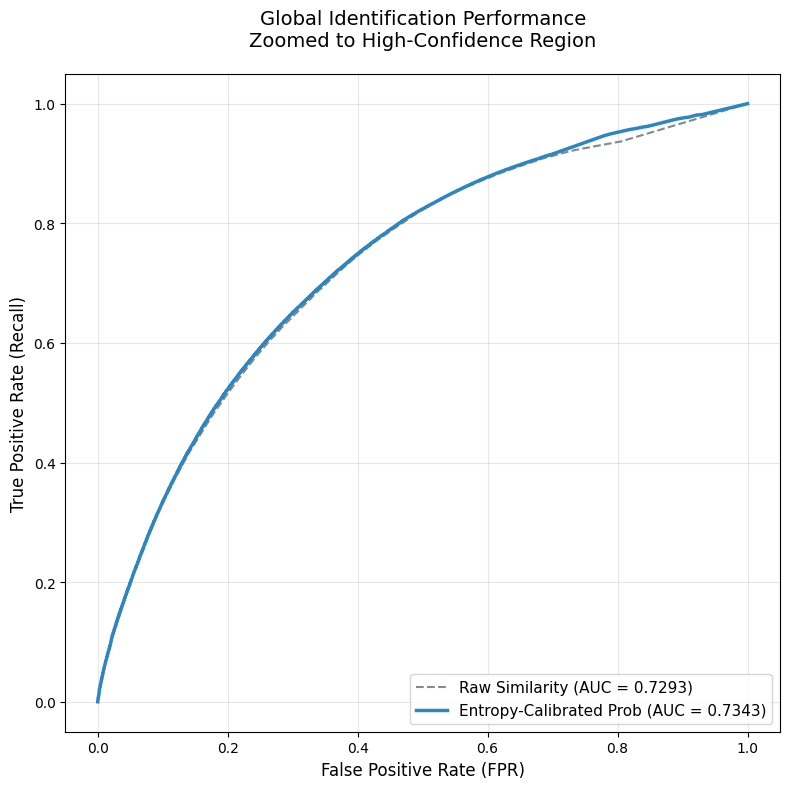

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Calculate ROC metrics
fpr_sim, tpr_sim, _ = roc_curve(hits_df['is_true'], hits_df['similarity'])
fpr_prob, tpr_prob, _ = roc_curve(hits_df['is_true'], hits_df['match_probability'])

plt.figure(figsize=(8, 8))

# 2. Plot both curves
plt.plot(fpr_sim, tpr_sim, color='#7F8C8D', linestyle='--', label=f'Raw Similarity (AUC = {auc(fpr_sim, tpr_sim):.4f})')
plt.plot(fpr_prob, tpr_prob, color='#2E86C1', linewidth=2.5, label=f'Entropy-Calibrated Prob (AUC = {auc(fpr_prob, tpr_prob):.4f})')

# # 3. Zoom into the "High Confidence" region (0-40% FPR)
# plt.xlim([0.0, 0.4]) 
# plt.ylim([0.6, 1.0])

# 4. Final formatting
plt.title("Global Identification Performance\nZoomed to High-Confidence Region", fontsize=14, pad=20)
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Compare precision in the high-score region
high_sim_cutoff = 0.7

high_sim_df = hits_df[hits_df['similarity'] >= high_sim_cutoff]

# Accuracy of raw similarity at this threshold
precision_raw = high_sim_df['is_true'].mean()

# Now look at the same number of top hits using Match Probability
top_n = len(high_sim_df)
top_prob_df = hits_df.sort_values('match_probability', ascending=False).head(top_n)
precision_prob = top_prob_df['is_true'].mean()

print(f"In the High-Score Region (> {high_sim_cutoff}):")
print(f"Raw Similarity Precision: {precision_raw:.4f}")
print(f"Calibrated Prob Precision: {precision_prob:.4f}")

In the High-Score Region (> 0.7):
Raw Similarity Precision: 0.5774
Calibrated Prob Precision: 0.5795


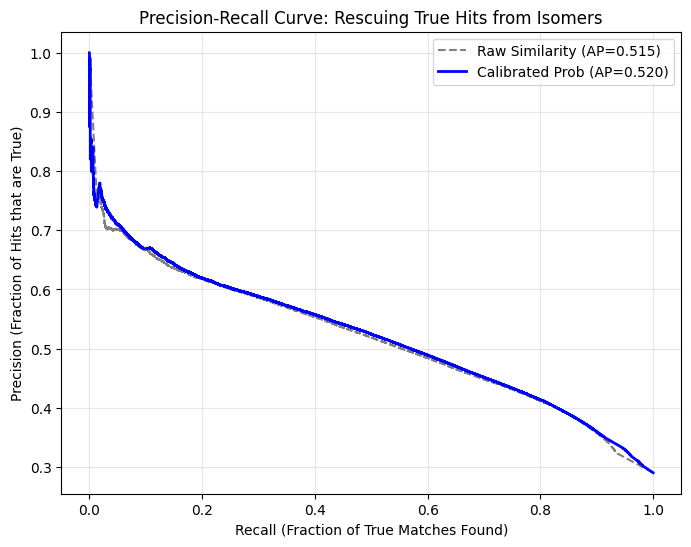

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate Precision-Recall values
prec_sim, rec_sim, _ = precision_recall_curve(hits_df['is_true'], hits_df['similarity'])
prec_prob, rec_prob, _ = precision_recall_curve(hits_df['is_true'], hits_df['match_probability'])

# Calculate Average Precision (AP)
ap_sim = average_precision_score(hits_df['is_true'], hits_df['similarity'])
ap_prob = average_precision_score(hits_df['is_true'], hits_df['match_probability'])

plt.figure(figsize=(8, 6))
plt.plot(rec_sim, prec_sim, label=f'Raw Similarity (AP={ap_sim:.3f})', color='gray', linestyle='--')
plt.plot(rec_prob, prec_prob, label=f'Calibrated Prob (AP={ap_prob:.3f})', color='blue', linewidth=2)

plt.xlabel('Recall (Fraction of True Matches Found)')
plt.ylabel('Precision (Fraction of Hits that are True)')
plt.title('Precision-Recall Curve: Rescuing True Hits from Isomers')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [70]:
# build a dict: bin -> sorted numpy array of null similarities
null_sorted = {}
for b, vals in formula_null.items():
    arr = np.array(vals, dtype=float)
    arr = arr[~np.isnan(arr)]
    arr.sort()  # ascending
    null_sorted[b] = arr

# also build a pooled fallback for bins that are empty or missing
pooled_all = np.concatenate([v for v in null_sorted.values() if len(v) > 0])
pooled_all.sort()


In [ ]:
# End of 

In [71]:
def pvals_for_bin(sim_values, arr_sorted):
    """
    sim_values: 1D np.array of observed similarities for this bin
    arr_sorted: sorted null similarities for this bin (ascending)
    returns: vector of empirical p-values (right tail)
    """
    n = len(arr_sorted)
    if n == 0:
        # caller will handle fallback
        return np.full_like(sim_values, fill_value=np.nan, dtype=float)

    idx = np.searchsorted(arr_sorted, sim_values, side="left")
    exceed_counts = n - idx
    # +1 smoothing to avoid 0
    pvals = (1 + exceed_counts) / (1 + n)
    return pvals


In [78]:
# Prepare output array of NaN
p_emp = np.full(shape=len(hits_df), fill_value=np.nan, dtype=float)

# We'll group hits_df by entropy_bin
for b, sub_idx in hits_df.groupby("entropy_bin").groups.items():
    # sub_idx is the index labels (could be Int64Index)
    sub_idx = np.array(list(sub_idx))

    # pull the observed similarities for those rows
    sim_vals = hits_df.loc[sub_idx, "similarity"].to_numpy(dtype=float)

    # choose the appropriate null array
    arr_sorted = null_sorted.get(int(b), np.array([], dtype=float))
    if arr_sorted.size == 0:
        # fallback to pooled_all
        arr_sorted = pooled_all

    # compute p-values for this bin, vectorized
    pvals = pvals_for_bin(sim_vals, arr_sorted)

    # store back
    p_emp[sub_idx] = pvals

# assign to dataframe
hits_df["p_emp"] = p_emp


In [79]:
# compute locally adjusted p values

from statsmodels.stats.multitest import multipletests

# Container for adjusted p-values
hits_df["p_adj_local"] = np.nan

# Loop by query spectrum
for qid, sub in hits_df.groupby("query_id"):
    if len(sub) < 2:
        continue  # skip trivial cases
    
    valid = sub["p_emp"].notna()
    if valid.sum() == 0:
        continue

    # Apply BH within this query
    _, p_adj_local, _, _ = multipletests(sub.loc[valid, "p_emp"], method="fdr_bh")

    hits_df.loc[sub.index[valid], "p_adj_local"] = p_adj_local


KeyboardInterrupt: 

In [74]:
# Collapse BEFORE correction
hits_unique = hits_df.sort_values('p_emp').drop_duplicates(
    subset=['query_id', 'inchikey'], keep='first'
)

# Apply BH to smaller set
hits_unique['p_adj'] = hits_unique.groupby('query_id')['p_emp'].transform(
    lambda p: multipletests(p, method='fdr_bh')[1]
)

KeyError: Index(['inchikey'], dtype='object')

--------------------------

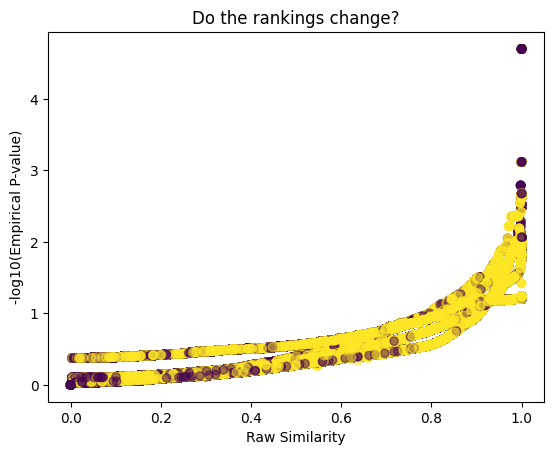

In [75]:
import matplotlib.pyplot as plt

# Compare Raw Similarity vs -log(P-value)
plt.scatter(hits_df['similarity'], -np.log10(hits_df['p_emp']), c=hits_df['is_true'], alpha=0.5)
plt.xlabel("Raw Similarity")
plt.ylabel("-log10(Empirical P-value)")
plt.title("Do the rankings change?")
plt.show()